# Разработка A/B-тестирования и анализ результатов

**Автор:** Кропотов Валентин **Дата:** 15.11.2025

Кампания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В этом приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Задаем переменную с датафреймом с историческими данными
sessions_history = pd.read_csv('sessions_project_history.csv')

In [3]:
# Выводим первые пять строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Группируем и сортируем уникальных пользователей по количеству уникальных сессий
sorted_users = sessions_history.groupby('user_id').agg({'session_id':'nunique'}).sort_values(by='session_id', ascending=False)

# Выводим осторические данные для одного из пользователей с максимальным количеством уникальных сессий
sessions_history[sessions_history['user_id'] == sorted_users.index[0]]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням

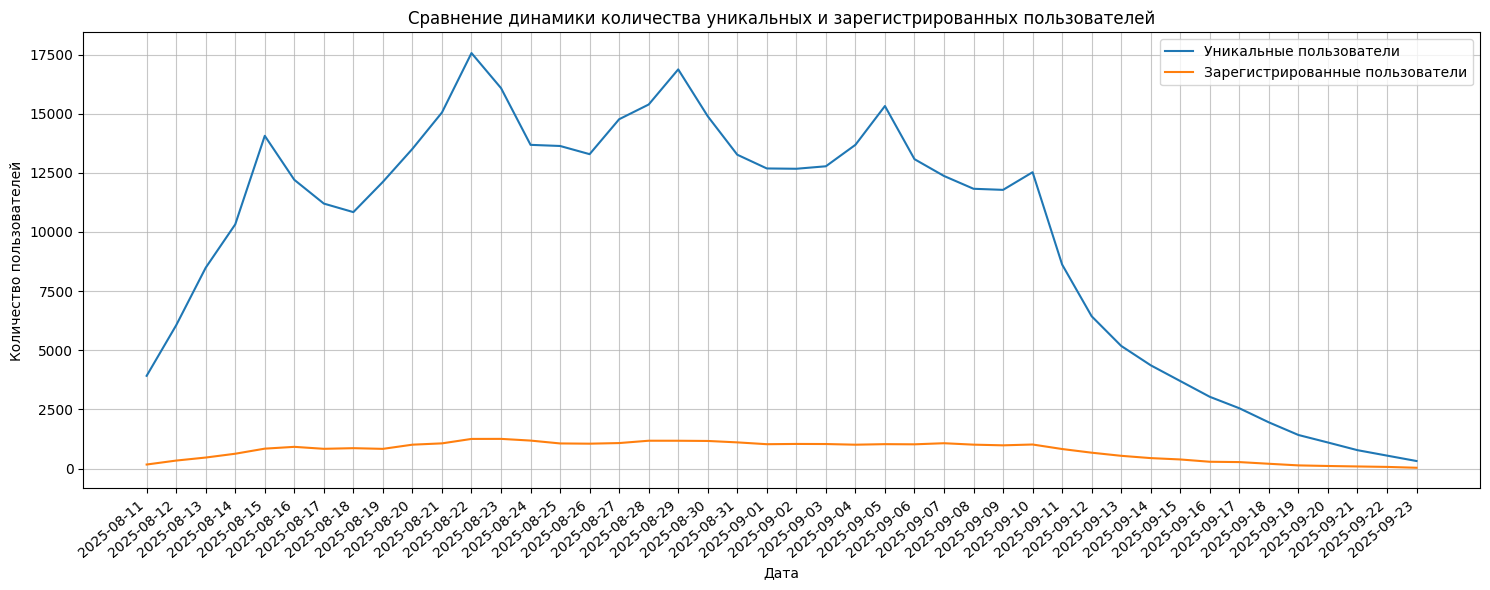

In [5]:
# Группируем данные по дате сессии и считаем уникальных и зарегистрированных пользователей
df_grp = sessions_history.groupby('session_date').agg({'user_id':'nunique',
                                                       'registration_flag':'sum'}).reset_index()

# Строим график
x = df_grp.session_date
y_a = df_grp.user_id
y_b = df_grp.registration_flag

plt.figure(figsize=(15, 6))
plt.plot(x, y_a, label ='Уникальные пользователи')
plt.plot(x, y_b, label ='Зарегистрированные пользователи')

plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=40, ha='right') # Поворот подписей по оси X и выравнивание их по правому краю
plt.grid(True, alpha=0.7)
plt.legend()
plt.title('Сравнение динамики количества уникальных и зарегистрированных пользователей')
plt.tight_layout()

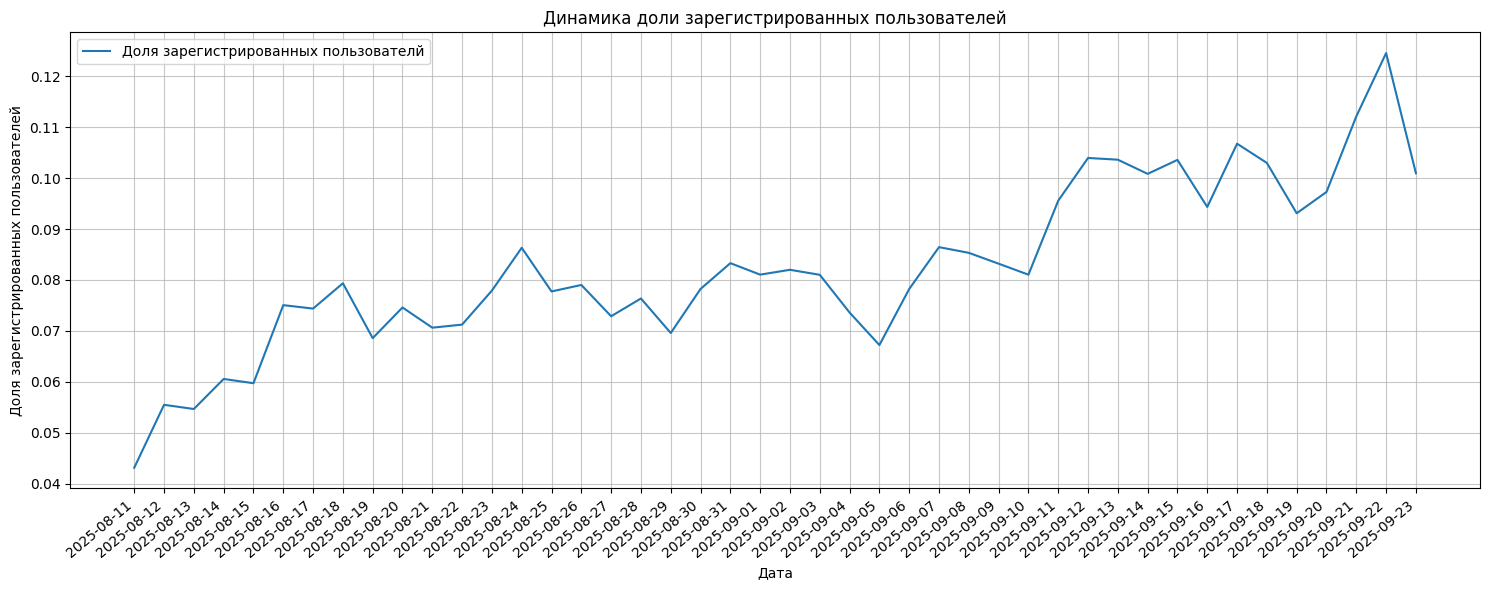

In [6]:
# Группируем данные по дате и считаем долю зарегистрированных пользователей
df_reg_mean = sessions_history.groupby('session_date').agg({'registration_flag':'mean'}).reset_index()

# Строим график
x = df_reg_mean.session_date
y = df_reg_mean.registration_flag

plt.figure(figsize=(15,6))
plt.plot(x, y, label='Доля зарегистрированных пользователй')

plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.title('Динамика доли зарегистрированных пользователей')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдем количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

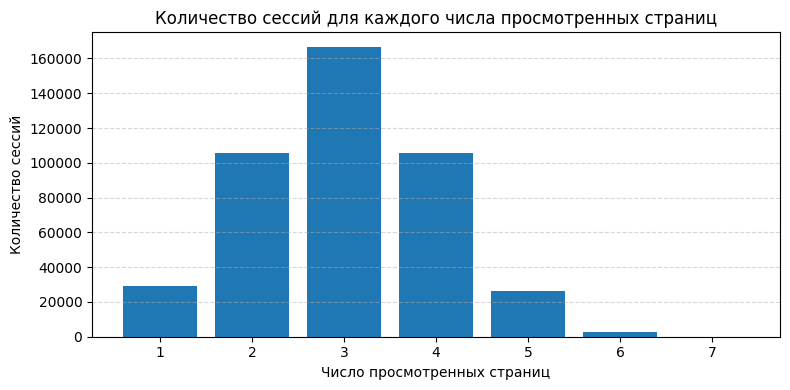

In [7]:
# Группируем данные по числу просмотренных страниц и считаем количество сессий для каждого числа
ses_count = sessions_history.groupby('page_counter').agg({'session_id':'nunique'}).reset_index()

# Строим график
x = ses_count.page_counter
y = ses_count.session_id

plt.figure(figsize=(8,4))
plt.bar(x, y)

plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.title('Количество сессий для каждого числа просмотренных страниц')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

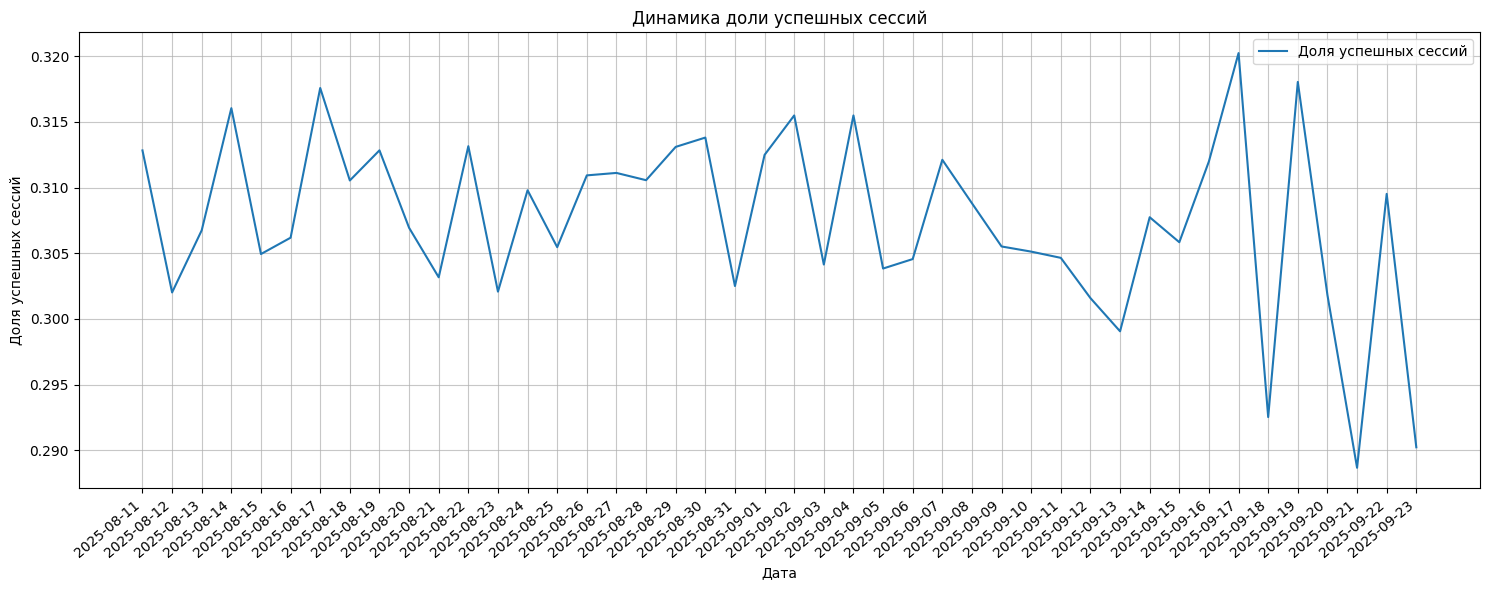

In [8]:
sessions_history['good_session'] = 0 # Добавляем новый столбец с бинарными значениеми
sessions_history.loc[sessions_history['page_counter']>=4, 'good_session'] = 1 # Для строк с просмотренными страницами 4 и больше меняем значение на 1

# Группируем данные по дате и считаем долю хороших сессий
good_ses_mean = sessions_history.groupby('session_date').agg({'good_session':'mean'}).reset_index()

# Строим график
x = good_ses_mean.session_date
y = good_ses_mean.good_session

plt.figure(figsize=(15,6))
plt.plot(x, y, label='Доля успешных сессий')

plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.title('Динамика доли успешных сессий')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Сформулируем нулевую и альтернативную гипотезы:

- **Нулевая гипотеза:** доля успешных сессий не изменилась.
- **Альтернативная гипотеза:** доля успешных сессий возросла.

#### 2.2. Расчёт размера выборки

Рассчитаем необходимое для вашего эксперимента количество пользователей. Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [9]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [10]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size*2)/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {round(avg_daily_users)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведите на экран процентную разницу в количестве пользователей в группах A и B.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

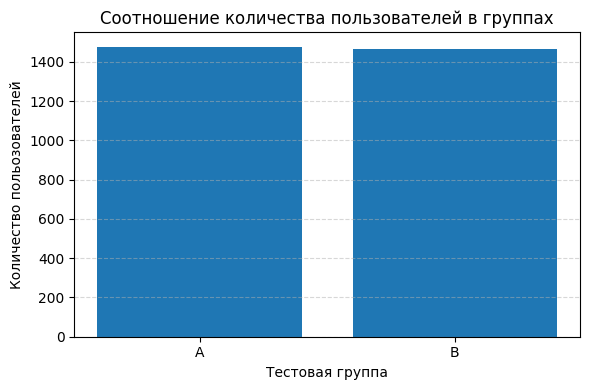

Процентная разница в количестве пользователей в группах состовляет 0.74%


In [11]:
# Считываем файл с данными с одним днем теста
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

# Поскольку в датасете только один день, нужно сгруппировать по группам и посчитать уникальных польозователей
users_count = sessions_test_part.groupby('test_group').agg({'user_id':'nunique'}).reset_index()

# Строим визуализацию
x = users_count['test_group']
y = users_count['user_id']

plt.figure(figsize=(6,4))
plt.bar(x, y)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.xlabel('Тестовая группа')
plt.ylabel('Количество польозователей')
plt.title('Соотношение количества пользователей в группах')
plt.tight_layout()
plt.show() # Чтобы вывод через print отображался под графиком

# Считаем процентную разницу количества пользователей в группах
P = 100*(abs(users_count.iloc[0,1]-users_count.iloc[1,1]))/users_count.iloc[0,1]
print(f'Процентная разница в количестве пользователей в группах состовляет {P:.2f}%')

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [12]:
# Собираем id пользователей в группах A и B в разные переменные
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

# Выводим список пересечения множеств id в группах A и B
list(set(group_a) & set(group_b))

[]

- Пользователей, которые встречались бы в обеих группах, не обнаружено.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

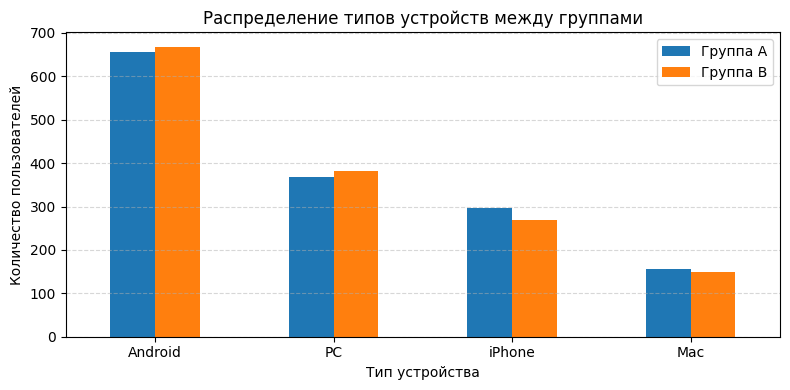

In [13]:
# Группируем данные по типу устройства и группе и считаем уникальных пользователй. Метод unstack для построения "двойного" графика.
device_dist = sessions_test_part.groupby(['device', 'test_group']).agg({'user_id':'nunique'}).unstack().sort_values(by=('user_id', 'A'), ascending=False)

# Строим визуализацию
device_dist.plot(kind='bar',
                figsize=(8, 4),
                rot=0,
                xlabel='Тип устройства',
                ylabel='Количество пользователей',
                title='Распределение типов устройств между группами')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(labels=['Группа A','Группа B'])
plt.tight_layout()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

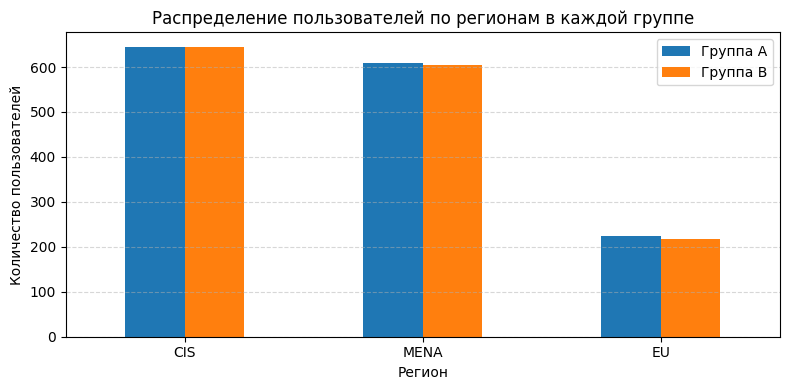

In [14]:
# Группируем данные по региону и группе и считаем уникальных пользователй.
region_dist = sessions_test_part.groupby(['region', 'test_group']).agg({'user_id':'nunique'}).unstack().sort_values(by=('user_id', 'A'), ascending=False)

# Строим график
region_dist.plot(kind='bar',
                figsize=(8,4),
                rot=0,
                xlabel='Регион',
                ylabel='Количество пользователей',
                title='Распределение пользователей по регионам в каждой группе')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(labels=['Группа A','Группа B'])
plt.tight_layout()

#### 3.5. Вывод после проверки A/B-теста

- Различие в количстве пользователей между группами является незначительным - `0.74%`.
- Пересечение пользователей между группами не было обнаружено.
- Распределение категориальных переменных `регион` и `тип устройства` между группами достаточно равномерное.

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [15]:
# Считываем файл с датасетом и присваиваем его переменной
sessions_test = pd.read_csv('sessions_project_test.csv')

# Добавляем столбец с бинарными значениями
sessions_test['good_session'] = 0
sessions_test.loc[sessions_test['page_counter']>=4, 'good_session'] = 1

# Проверяем
sessions_test.sample(n=5, random_state=3)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
19127,E397004ADA5B6597,8E228AA8369C337F,2025-10-17,2025-10-17 20:02:42,2025-10-17,1,0,2,CIS,Mac,B,0
80729,985826E4E02A5988,7E6952EDAF02F101,2025-10-25,2025-10-25 19:35:37,2025-10-20,4,0,4,CIS,Android,A,1
33435,21A68AFC5A8F350C,C6A69F1B8F9403FE,2025-10-19,2025-10-19 16:31:15,2025-10-16,3,1,4,EU,Android,B,1
11885,6D950A91E30225D5,6F7634329A830595,2025-10-15,2025-10-15 20:29:19,2025-10-15,1,0,1,MENA,Android,B,0
9660,C49299FC4BFD7736,1D7338EB926D885E,2025-10-21,2025-10-21 22:15:36,2025-10-18,2,0,4,EU,iPhone,A,1


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

In [16]:
# Считаем уникальное количество сессий за каждый день для каждой группы
sessions_count = sessions_test.groupby(['session_date','test_group']).agg({'session_id':'nunique'}).reset_index()

# Формируем серии для групп
group_a = sessions_count[sessions_count.test_group=='A']['session_id']
group_b = sessions_count[sessions_count.test_group=='B']['session_id']

# Проводим двухвыборочный t-тест Стъюдента с двусторонней альтернативной гипотезой
stat_ttest, p_value_ttest = ttest_ind(group_a,
                                      group_b,
                                      alternative='two-sided')
p_value_ttest

0.9382193048591161

- Такое значение `p-value` говорит о том, что с вероятностью `~94%` такие данные могли получиться, если нулевая гипотеза была верна. Нулевая гипотеза в нашем случае - количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимы. Таким образом можно с большой долей вероятности утверждать, что разница в количестве сессий в группах статистически не значимо.

#### 4.3. Сравнение доли успешных сессий

Когда мы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [17]:
good_ses_mean = sessions_test.groupby('test_group').agg({'good_session':'mean'})

good_ses_diff = round(good_ses_mean.iloc[1,0] - good_ses_mean.iloc[0,0],3)

print(f'''
{good_ses_mean}\n
Разница доли успешных сессий между группами {good_ses_diff}
''')


            good_session
test_group              
A               0.307723
B               0.318290

Разница доли успешных сессий между группами 0.011



#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

In [18]:
# Считаем количество наблюдений и успехов в каждой группе
n_a, n_b = sessions_test[sessions_test['test_group']=='A'].shape[0], sessions_test[sessions_test['test_group']=='B'].shape[0]
m_a = sessions_test[sessions_test['test_group']=='A']['good_session'].sum()
m_b = sessions_test[sessions_test['test_group']=='B']['good_session'].sum()

# Проверяем достаточность размера выборок (зачем-то, в задании такого нет, но удалять уже не хочется)
p_a, p_b = m_a/n_a, m_b/n_b

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [19]:
# Проводим Z-тест пропорций
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest([m_a, m_b],
                                              [n_a, n_b],
                                              alternative='smaller')
print(f'Значение p-value: {p_value_ztest} при уровне значимости: {alpha}.')

Значение p-value: 0.0001574739988036123 при уровне значимости: 0.05.


- P-value меньше уровня значимости, таким образом данные свидетельствуют в пользу альтернативной гипотезы. Альтернативная гипотеза - метрика среднего количества успешных сессий в группе B больше, чем в группе A.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируем выводы для команды разработки приложения. В выводе укажем:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

In [20]:
# Длительность эксперимента
len_exp = sessions_test['session_date'].nunique()

# Количество уникальных и не уникальных пользователей
users_count = sessions_test['user_id'].count()
users_unique = sessions_test['user_id'].nunique()

print(f'Эксперимент длился {len_exp} дней и в нем было задействовано {users_unique} уникальных и {users_count} не уникальных пользователей.')

Эксперимент длился 20 дней и в нем было задействовано 30579 уникальных и 100005 не уникальных пользователей.


- Внедрение нового алгоритма статистически значимым образом повлияло на ключевую метрику в группе B в сторону ее увеличения.
- P-value получилось равным `0.0001574739988036123`.
- Исходя из полученных данных можно сказать, что внедрение нововвидения положительно сказалось на ключевой метрике. Значит нововведение стоит внедрять.